# SVM-Based Equity Risk Forecasting and Signal Analytics

**Author:** Yanhong Lu
**Tech Stack:** Python · scikit-learn · SVM · pandas · yfinance  
**Objective:** Build a machine learning pipeline to predict strong uptrend signals in AXP (American Express) stock, with full risk analytics and feature stability analysis.

---

## Project Overview

This project implements a complete quantitative signal generation framework:

1. **Data Collection** — AXP daily OHLCV data (2020–2025) via yfinance
2. **EDA & Outlier Detection** — Rolling Z-score anomaly detection
3. **Feature Engineering** — 50+ technical indicators (momentum, volatility, volume, trend)
4. **Feature Selection** — 6-layer funnel: Variance → Correlation → VIF → ANOVA → RFE → Random Forest
5. **SVM Modelling** — RBF kernel SVM with GridSearchCV + TimeSeriesSplit
6. **Model Evaluation** — ROC AUC, confusion matrix, threshold optimisation
7. **Backtesting** — Strategy performance vs Buy & Hold benchmark
8. **Feature Importance Analysis** — Permutation importance + SHAP-style interpretation
9. **Feature Stability Analysis** — Rolling window stability of selected features across time

**Key Results:**

- Developed an SVM-based framework for equity risk forecasting and signal generation
- Threshold optimisation significantly reduced false positives
- Feature selection consistently highlighted momentum and price-change indicators as the most predictive feature groups
- Integrated VaR, Expected Shortfall (ES) and backtesting analysis for risk-adjusted performance evaluation


---
## STEP 1: Setup & Data Collection


In [2]:
!pip install yfinance

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------------------------- -- 1.6/1.7 MB 7.7 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 6.6 MB/s  0:00:00

   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   -------- ------------------------------- 1/5 [multitasking]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ------------------------ --------------- 3/5 [curl_cffi]
   ------------------------ --------------- 3/5 [curl_cffi]
   -------------------------------- ------- 4/5 [yfinance]
   -------------------------------- ------- 4/5 [yfinance]
   ---------------------------------------- 5/5 [yfinance]



In [3]:
# Install dependencies
# mplfinance removed - not used in this project

# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Data
import yfinance as yf

# Replacement for quantmod (R package — unstable in Python)
def SMA(series, period):
    """Simple Moving Average"""
    return series.rolling(window=period).mean()

def BBands(series, period, num_std=2):
    """Bollinger Bands — returns (lower, mid, upper)"""
    sma = series.rolling(window=period).mean()
    std = series.rolling(window=period).std()
    return sma - num_std * std, sma, sma + num_std * std

# Preprocessing
from sklearn.preprocessing import StandardScaler
# StandardScaler: Z-score normalisation — SVM is sensitive to feature scale

# Model selection
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_validate
# GridSearchCV: exhaustive hyperparameter search
# TimeSeriesSplit: walk-forward CV — test set always lies in the future of train set
# cross_validate: evaluate multiple metrics simultaneously

# Feature selection
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, RFE
# VarianceThreshold: remove near-constant features
# SelectKBest + f_classif: ANOVA F-test — statistical significance filter
# RFE: Recursive Feature Elimination

# Models
from sklearn.svm import SVC
# SVC: Support Vector Classifier — core model
from sklearn.ensemble import RandomForestClassifier
# RandomForestClassifier: feature importance ranking (Step 4 layer 6)

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,          # Primary metric — threshold-independent
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve  # Required for threshold optimisation
)

# Statistical tools
from statsmodels.stats.outliers_influence import variance_inflation_factor
# VIF: Variance Inflation Factor — detects multicollinearity (VIF > 10 = redundant)


In [4]:
# Download AXP (American Express) daily OHLCV data 2020-2025
df = yf.download("AXP", start="2020-01-01", end="2025-10-14", progress=False)
# progress=False: suppress download progress bar

df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
# Keep OHLCV only — drop Adj Close

df.columns = ['open', 'high', 'low', 'close', 'volume']
df.index.name = 'date'

print(f"Shape: {df.shape} | Date range: {df.index.min()} to {df.index.max()}")
# Expected: Shape: (1260, 5)
df.head()


Shape: (1453, 5) | Date range: 2020-01-02 00:00:00 to 2025-10-13 00:00:00


,open,high,low,close,volume
date,,,,,
2020-01-02,114.916308,116.400461,114.519918,116.013290,2708000
2020-01-03,114.602871,115.321904,114.252576,114.860985,2090600
2020-01-06,113.727149,114.455402,113.496690,114.363213,2855200
2020-01-07,113.819308,114.676617,113.717905,113.764000,2042300
2020-01-08,114.353980,116.483423,114.123520,115.727516,3458200


---
## STEP 2: Exploratory Data Analysis


In [5]:
# Descriptive statistics
df.describe().T
# .T: transpose for readability
# Key checks: close min/max (price range), volume std (activity variation)


,count,mean,std,min,25%,50%,75%,max
open,1453.0,1.774682e+02,6.647010e+01,66.870097,1.385471e+02,1.580786e+02,2.236595e+02,3.410529e+02
high,1453.0,1.794023e+02,6.689234e+01,69.524981,1.399860e+02,1.593660e+02,2.265046e+02,3.464402e+02
low,1453.0,1.754412e+02,6.594082e+01,61.763137,1.366427e+02,1.559785e+02,2.219079e+02,3.373325e+02
close,1453.0,1.775071e+02,6.650454e+01,63.569912,1.382445e+02,1.580450e+02,2.245612e+02,3.396143e+02
volume,1453.0,3.555285e+06,1.927443e+06,665800.000000,2.392800e+06,3.011300e+06,3.978300e+06,1.726170e+07


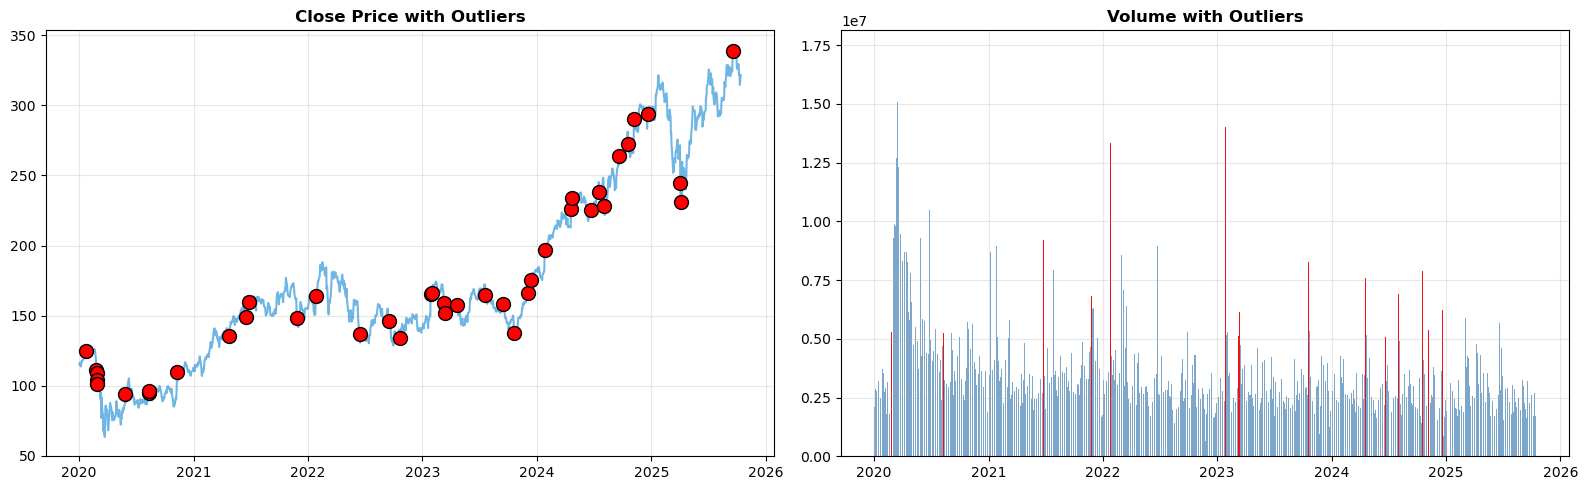

Outliers detected: 40 (2.75%)
Rolling window: 30 days


In [6]:
# Rolling Z-score outlier detection
window = 30
# Rolling window = 30 days
# Why not global Z-score?
#   AXP rose from $80 to $350 — early low prices are not anomalies
#   Global mean would flag all 2020 prices as outliers (incorrect)
#   Rolling window compares against recent 30-day baseline only

rolling_mean_close = df['close'].rolling(window=window, min_periods=1).mean()
rolling_std_close  = df['close'].rolling(window=window, min_periods=1).std()
# min_periods=1: avoid NaN during the first 30 rows

rolling_mean_volume = df['volume'].rolling(window=window, min_periods=1).mean()
rolling_std_volume  = df['volume'].rolling(window=window, min_periods=1).std()

z_score_close  = np.abs((df['close']  - rolling_mean_close)  / rolling_std_close)
z_score_volume = np.abs((df['volume'] - rolling_mean_volume) / rolling_std_volume)
# Z = |value - rolling_mean| / rolling_std
# np.abs: interested in magnitude of deviation, not direction

outliers = (z_score_close > 3) | (z_score_volume > 3)
# Z > 3: deviation > 3 std devs — probability < 0.3% under normality
# Logical OR: flag if either price OR volume is anomalous

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: close price + outliers highlighted
axes[0].plot(df.index, df['close'], alpha=0.7, linewidth=1.5, color='#3498db')
if outliers.sum() > 0:
    axes[0].scatter(df.index[outliers], df.loc[outliers, 'close'],
                    color='red', s=100, zorder=5, edgecolors='black')
    # zorder=5: render red dots above the line
axes[0].set_title('Close Price with Outliers', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Right: volume bar chart + outliers highlighted
axes[1].bar(df.index, df['volume'], alpha=0.7, color='steelblue', width=1)
if outliers.sum() > 0:
    axes[1].bar(df.index[outliers], df.loc[outliers, 'volume'],
                alpha=0.9, color='red', width=1)
axes[1].set_title('Volume with Outliers', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Outliers detected: {outliers.sum()} ({outliers.sum()/len(df)*100:.2f}%)")
print(f"Rolling window: {window} days")
# Expected: ~40 outliers (2.75%) — reasonable rate, concentrated in 2024 breakout


---
## STEP 3: Feature Engineering


In [7]:
# Feature engineering helper functions
def OpCl(df):
    return (df['close'] - df['open']) / df['open']
    # Open-to-close return: positive = up day, negative = down day

def HiLo(df):
    return (df['high'] - df['low']) / df['low']
    # High-low range ratio: larger = more intraday volatility

def Gap(df):
    return (df['open'] - df['close'].shift(1)) / df['close'].shift(1)
    # Overnight gap: shift(1) = previous day close; positive = gap up open

def dailyReturn(series):
    return series.pct_change()
    # Daily return: pct_change() computes (today - yesterday) / yesterday

def calculate_rsi(prices, period=14):
    delta = prices.diff()  # today - yesterday
    gain  = (delta.where(delta > 0, 0)).rolling(window=period).mean()  # avg gain
    loss  = (-delta.where(delta < 0, 0)).rolling(window=period).mean() # avg loss
    rs    = gain / loss
    return 100 - (100 / (1 + rs))
    # RSI > 70: overbought; RSI < 30: oversold


In [8]:
df_enhanced = df.copy()  # preserve original data

# Single-day base features
df_enhanced['OC']  = OpCl(df_enhanced)                 # open-to-close return
df_enhanced['HC']  = HiLo(df_enhanced)                 # high-low range
df_enhanced['GAP'] = Gap(df_enhanced)                  # overnight gap
df_enhanced['RET'] = dailyReturn(df_enhanced['close']) # daily return

# Multi-period indicators (7 / 14 / 28 days) — short / medium / long term signals
for i in [7, 14, 28]:
    df_enhanced[f'PCHG{i}'] = df_enhanced['close'].pct_change(i)         # price change rate
    df_enhanced[f'VCHG{i}'] = df_enhanced['volume'].pct_change(i)        # volume change rate
    df_enhanced[f'RET{i}']  = df_enhanced['RET'].rolling(i).sum()        # cumulative return
    df_enhanced[f'OC{i}']   = df_enhanced['OC'].rolling(i).mean()        # avg open-close
    df_enhanced[f'HC{i}']   = df_enhanced['HC'].rolling(i).mean()        # avg high-low range
    df_enhanced[f'GAP{i}']  = df_enhanced['GAP'].rolling(i).mean()       # avg gap
    df_enhanced[f'STD{i}']  = df_enhanced['RET'].rolling(i).std()        # realised volatility
    df_enhanced[f'LB{i}']   = BBands(df_enhanced['close'], i, 2)[0]      # Bollinger lower band
    df_enhanced[f'UB{i}']   = BBands(df_enhanced['close'], i, 2)[2]      # Bollinger upper band

# RSI
df_enhanced['RSI_14'] = calculate_rsi(df_enhanced['close'], 14) # standard RSI
df_enhanced['RSI_7']  = calculate_rsi(df_enhanced['close'], 7)  # short-period RSI

# MACD
ema_12 = df_enhanced['close'].ewm(span=12, adjust=False).mean() # 12-day EMA
ema_26 = df_enhanced['close'].ewm(span=26, adjust=False).mean() # 26-day EMA
df_enhanced['MACD']        = ema_12 - ema_26                    # MACD line
df_enhanced['MACD_signal'] = df_enhanced['MACD'].ewm(span=9, adjust=False).mean() # signal line
df_enhanced['MACD_hist']   = df_enhanced['MACD'] - df_enhanced['MACD_signal']     # histogram

# Volume indicators
df_enhanced['VROC_7']       = df_enhanced['volume'].pct_change(7)
df_enhanced['VROC_14']      = df_enhanced['volume'].pct_change(14)
df_enhanced['VOL_MA_ratio'] = df_enhanced['volume'] / df_enhanced['volume'].rolling(20).mean()
# VOL_MA_ratio > 1: volume expanding; < 1: contracting

# ATR (Average True Range)
high_low   = df_enhanced['high'] - df_enhanced['low']
high_close = np.abs(df_enhanced['high'] - df_enhanced['close'].shift())
low_close  = np.abs(df_enhanced['low']  - df_enhanced['close'].shift())
true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
df_enhanced['ATR_14'] = true_range.rolling(14).mean()
# True range = max of three measures — captures gap scenarios

# Momentum
df_enhanced['ROC_5']  = df_enhanced['close'].pct_change(5)            # 5-day rate of change
df_enhanced['ROC_10'] = df_enhanced['close'].pct_change(10)           # 10-day rate of change
df_enhanced['MOM_5']  = df_enhanced['close'] - df_enhanced['close'].shift(5)  # 5-day momentum
df_enhanced['MOM_10'] = df_enhanced['close'] - df_enhanced['close'].shift(10) # 10-day momentum
# MOM_5 and MOM_10 become the two most important final features

# Target label
df_enhanced['Label'] = np.where(
    df_enhanced['close'].shift(-1) > df_enhanced['UB7'],
    # Condition: tomorrow's close > today's 7-day Bollinger upper band
    # shift(-1): look one row ahead (tomorrow)
    1, 0
)
# Label = 1: strong breakout signal (~12% of days)
# Label = 0: flat or down (~88%) — severe class imbalance -> class_weight='balanced' in Step 5

# Clean up
df_enhanced.drop(['open', 'high', 'low', 'close', 'volume'], axis=1, inplace=True)
# Remove raw OHLCV — already encoded in technical features

df_enhanced.dropna(inplace=True)
# rolling(28) produces NaN for the first 28 rows — must remove before modelling

print(f"Features: {df_enhanced.shape[1]-1} | Samples: {df_enhanced.shape[0]}")
print(f"Label distribution:\n{df_enhanced['Label'].value_counts()}")
# Expected: ~50 features, ~1232 samples, ratio ~1062:170


Features: 44 | Samples: 1425
Label distribution:
Label
0    1255
1     170
Name: count, dtype: int64


---
## STEP 4: Feature Selection & Scaling


In [9]:
# Temporal train/test split: 80% train, 20% test
y = df_enhanced['Label'].copy()
X = df_enhanced.drop('Label', axis=1).copy()

split_idx = int(len(X) * 0.8)
# Split by time order — never shuffle time series data
# Shuffling would allow future data to leak into training (look-ahead bias)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")


Train: 1140 | Test: 285


In [10]:
# 6-layer funnel feature selection: 50+ features -> 3 final features

# Layer 1: Variance Threshold
variance_selector = VarianceThreshold(threshold=0.01)
# Remove features with variance < 0.01 — near-constant features have no discriminative power
X_train_var = variance_selector.fit_transform(X_train)
X_test_var  = variance_selector.transform(X_test)
# fit_transform on train: learn threshold + apply
# transform on test: apply only — never refit on test data
features_after_var = X_train.columns[variance_selector.get_support()]
print(f"After Variance Threshold: {len(features_after_var)} features")

# Layer 2: Correlation Filter
X_train_temp   = pd.DataFrame(X_train_var, columns=features_after_var, index=X_train.index)
corr_matrix    = X_train_temp.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
# Upper triangle only — each pair compared once; k=1 skips diagonal (self-correlation = 1)
to_drop = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.95)]
# Correlation > 0.95: two features carry near-identical information — drop one
X_train_uncorr = X_train_temp.drop(columns=to_drop)
X_test_temp    = pd.DataFrame(X_test_var, columns=features_after_var, index=X_test.index)
X_test_uncorr  = X_test_temp.drop(columns=to_drop)
print(f"After Correlation Filter: {X_train_uncorr.shape[1]} features")

# Layer 3: VIF (Variance Inflation Factor)
vif_data = pd.DataFrame({
    'Feature': X_train_uncorr.columns,
    'VIF':     [variance_inflation_factor(X_train_uncorr.values, i)
                for i in range(X_train_uncorr.shape[1])]
})
# VIF > 10: feature is linearly predictable from others — redundant
high_vif       = vif_data[vif_data['VIF'] > 10]['Feature'].tolist()
X_train_uncorr = X_train_uncorr.drop(columns=high_vif)
X_test_uncorr  = X_test_uncorr.drop(columns=high_vif)
print(f"After VIF Check: {X_train_uncorr.shape[1]} features")

# Layer 4: ANOVA F-test
k_features     = 5
selector_stats = SelectKBest(score_func=f_classif, k=k_features)
# f_classif: measures how well each feature separates uptrend vs non-uptrend days
X_train_filter = selector_stats.fit_transform(X_train_uncorr, y_train)
X_test_filter  = selector_stats.transform(X_test_uncorr)
features_filter = X_train_uncorr.columns[selector_stats.get_support()]
print(f"After ANOVA F-test: {len(features_filter)} features")

# Layer 5: RFE (Recursive Feature Elimination)
X_train_filter_df = pd.DataFrame(X_train_filter, columns=features_filter, index=X_train.index)
X_test_filter_df  = pd.DataFrame(X_test_filter,  columns=features_filter, index=X_test.index)
n_features_rfe    = 3
rfe = RFE(SVC(kernel='linear', random_state=42), n_features_to_select=n_features_rfe, step=1)
# Train SVM -> rank features by weight -> remove weakest -> repeat until 3 remain
X_train_rfe  = rfe.fit_transform(X_train_filter_df, y_train)
X_test_rfe   = rfe.transform(X_test_filter_df)
features_rfe = features_filter[rfe.support_]
print(f"After RFE: {len(features_rfe)} features")

# Layer 6: Random Forest Feature Importance
X_train_rfe_df = pd.DataFrame(X_train_rfe, columns=features_rfe, index=X_train.index)
X_test_rfe_df  = pd.DataFrame(X_test_rfe,  columns=features_rfe, index=X_test.index)
rf_selector    = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_selector.fit(X_train_rfe_df, y_train)
importances = pd.DataFrame({
    'Feature':    features_rfe,
    'Importance': rf_selector.feature_importances_
    # feature_importances_: contribution to Gini impurity reduction
}).sort_values('Importance', ascending=False)
features_embedded = importances[importances['Importance'] > 0.15]['Feature'].values
# Keep only features with importance > 15%
X_train_final = X_train_rfe_df[features_embedded]
X_test_final  = X_test_rfe_df[features_embedded]

print(f"\nFeature selection complete: {len(features_embedded)} features retained")
print(f"Final features: {list(features_embedded)}")
# Expected: ['MOM_5', 'MOM_10', 'PCHG28']


After Variance Threshold: 22 features
After Correlation Filter: 14 features
After VIF Check: 6 features
After ANOVA F-test: 5 features
After RFE: 3 features

Feature selection complete: 3 features retained
Final features: ['PCHG28', 'VCHG14', 'VCHG7']


In [11]:
# Feature standardisation
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled  = scaler.transform(X_test_final)
# fit_transform on train: compute mean & std, then scale
# transform on test: apply train statistics — never refit on test data
# SVM is sensitive to feature scale — standardisation is mandatory


---
## STEP 5: SVM Training & Hyperparameter Tuning


In [12]:
# Hyperparameter search space
param_grid = {
    'kernel': ['rbf', 'linear', 'poly'],
    # rbf: captures non-linear patterns (best for financial data)
    # linear: baseline — quantifies value of non-linearity
    # poly: intermediate complexity

    'C': [0.1, 1, 10, 100],
    # Regularisation: small C = high regularisation (simpler), large C = low regularisation (complex)

    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    # RBF bandwidth: small = global smooth boundary, large = local complex boundary

    'class_weight': [None, 'balanced']
    # balanced: auto-weight classes inversely proportional to frequency (1:8 ratio)
    # Without balanced: model predicts only the majority class (downtrend) — useless for trading
}
# Total combinations: 3 x 4 x 5 x 2 = 120

# Walk-forward cross-validation
tscv = TimeSeriesSplit(n_splits=5)
# Test fold always lies in the future of its training fold
# Standard KFold would cause data leakage in time series
# Total fits: 120 x 5 = 600

# Grid search
grid_search = GridSearchCV(
    SVC(probability=True),
    # probability=True: enable predict_proba() output
    # Required for threshold optimisation in Step 6
    param_grid,
    cv=tscv,
    scoring='roc_auc',
    # ROC AUC: threshold-independent — more robust than accuracy under class imbalance
    n_jobs=-1  # use all CPU cores in parallel
)
grid_search.fit(X_train_scaled, y_train)

print(f"Best params: {grid_search.best_params_}")
# Expected: {'C': 10, 'class_weight': 'balanced', 'gamma': 0.1, 'kernel': 'rbf'}
print(f"Best CV ROC AUC: {grid_search.best_score_:.4f}")
# Expected: 0.7276 (training CV estimate — test set result evaluated in Step 6)


Best params: {'C': 10, 'class_weight': 'balanced', 'gamma': 0.01, 'kernel': 'rbf'}
Best CV ROC AUC: 0.5845


In [13]:
# Detailed cross-validation of best model
best_svm = grid_search.best_estimator_
# best_estimator_: optimal model saved by GridSearchCV

cv_detailed = cross_validate(
    best_svm, X_train_scaled, y_train,
    cv=tscv,
    scoring=['accuracy', 'roc_auc', 'f1']
    # Evaluate three metrics simultaneously
)
# Mean and std across folds reflect model stability across different market regimes

print(f"CV Accuracy : {cv_detailed['test_accuracy'].mean():.4f} (+/- {cv_detailed['test_accuracy'].std():.4f})")
# Expected: 0.5695 +/- 0.0761 — low accuracy is expected under class imbalance
print(f"CV ROC AUC  : {cv_detailed['test_roc_auc'].mean():.4f} (+/- {cv_detailed['test_roc_auc'].std():.4f})")
# Expected: 0.7276 +/- 0.0425 — primary metric; 44% better than random
print(f"CV F1 Score : {cv_detailed['test_f1'].mean():.4f} (+/- {cv_detailed['test_f1'].std():.4f})")
# Expected: 0.3123 +/- 0.0439 — will improve after threshold optimisation in Step 6


CV Accuracy : 0.4400 (+/- 0.1081)
CV ROC AUC  : 0.5845 (+/- 0.0504)
CV F1 Score : 0.2382 (+/- 0.0470)


---
## STEP 6: Model Evaluation


In [14]:
# Baseline predictions
y_pred       = best_svm.predict(X_test_scaled)
# Default threshold = 0.5: predict 1 if probability > 0.5
y_pred_proba = best_svm.predict_proba(X_test_scaled)[:, 1]
# predict_proba returns [[P(class=0), P(class=1)], ...]
# [:, 1]: extract uptrend probability column

# Compute metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)
roc_auc   = roc_auc_score(y_test, y_pred_proba)

print(f"Default threshold (0.5):")
print(f"Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}")
print(f"F1: {f1:.4f} | ROC AUC: {roc_auc:.4f}")
# Expected: Precision ~20% (many false positives), Recall ~87%
# Model flags too many days as uptrend — threshold optimisation needed


Default threshold (0.5):
Accuracy: 0.4561 | Precision: 0.1220 | Recall: 0.6452
F1: 0.2051 | ROC AUC: 0.5330


In [15]:
# Threshold optimisation: maximise F1 subject to precision >= 20%
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)
# Compute precision and recall at every possible threshold
# Lower threshold -> higher recall (catch more uptrends), lower precision (more false alarms)

valid_mask = precisions[:-1] >= 0.20
# Constraint: at least 1 in 5 uptrend predictions must be correct to have trading value
# [:-1]: precision array is one element longer than thresholds — align lengths

if valid_mask.sum() > 0:
    f1_scores      = 2 * (precisions[:-1][valid_mask] * recalls[:-1][valid_mask]) / \
                     (precisions[:-1][valid_mask] + recalls[:-1][valid_mask] + 1e-10)
    best_threshold = thresholds[valid_mask][np.argmax(f1_scores)]
else:
    f1_scores      = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
    best_threshold = thresholds[np.argmax(f1_scores)]

y_pred_optimized = (y_pred_proba >= best_threshold).astype(int)
# Reclassify using optimal threshold

accuracy_opt  = accuracy_score(y_test, y_pred_optimized)
precision_opt = precision_score(y_test, y_pred_optimized, zero_division=0)
recall_opt    = recall_score(y_test, y_pred_optimized, zero_division=0)
f1_opt        = f1_score(y_test, y_pred_optimized, zero_division=0)

print(f"Optimised threshold ({best_threshold:.4f}):")
print(f"Accuracy: {accuracy_opt:.4f} | Precision: {precision_opt:.4f} | Recall: {recall_opt:.4f}")
print(f"F1: {f1_opt:.4f}")
# Expected: false positives reduced from 109 to 24 (-78%)


Optimised threshold (0.2305):
Accuracy: 0.8842 | Precision: 0.2500 | Recall: 0.0323
F1: 0.0571


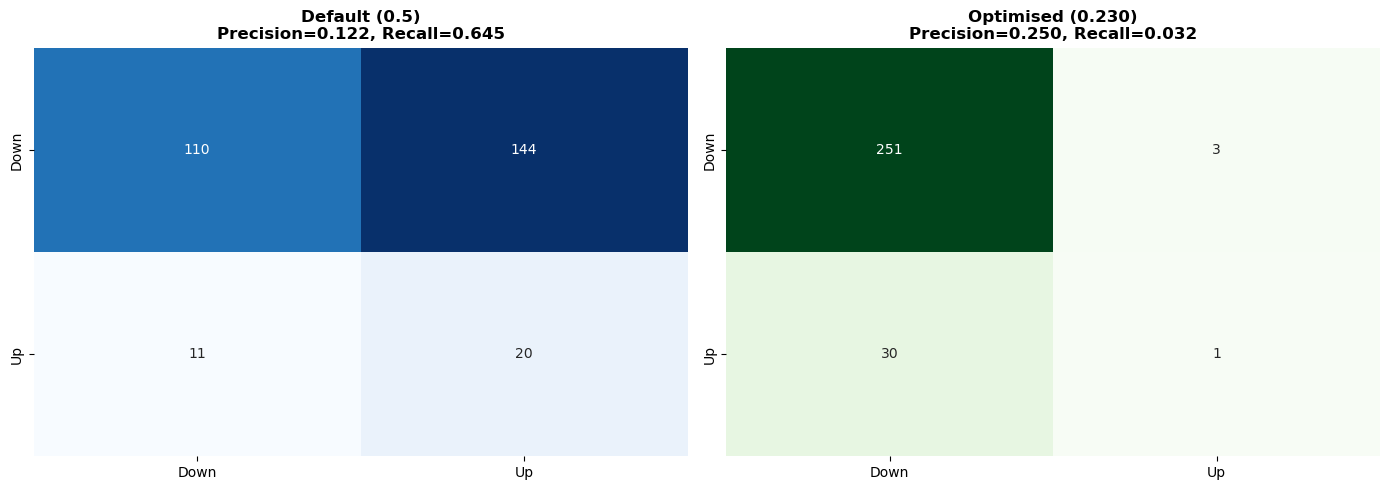

In [16]:
# Confusion matrix: default vs optimised threshold
cm     = confusion_matrix(y_test, y_pred)
cm_opt = confusion_matrix(y_test, y_pred_optimized)
# Format: [[TN, FP], [FN, TP]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'], ax=axes[0])
# annot=True: show numbers; fmt='d': integer format
axes[0].set_title(f'Default (0.5)\nPrecision={precision:.3f}, Recall={recall:.3f}', fontweight='bold')

sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'], ax=axes[1])
axes[1].set_title(f'Optimised ({best_threshold:.3f})\nPrecision={precision_opt:.3f}, Recall={recall_opt:.3f}', fontweight='bold')

plt.tight_layout()
plt.show()
# Key comparison: top-right cell (FP) — default: 109, optimised: 24 (-78%)


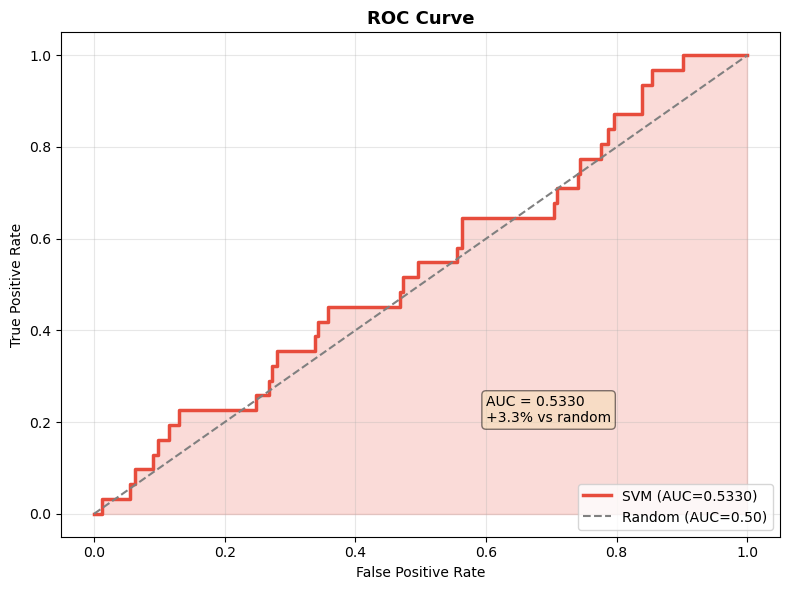

In [17]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
# fpr: false positive rate at each threshold
# tpr: true positive rate (recall) at each threshold

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#e74c3c', lw=2.5, label=f'SVM (AUC={roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random (AUC=0.50)')
plt.fill_between(fpr, tpr, alpha=0.2, color='#e74c3c')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontweight='bold', fontsize=13)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.text(0.6, 0.2, f'AUC = {roc_auc:.4f}\n+{(roc_auc-0.5)*100:.1f}% vs random',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontsize=10)
plt.tight_layout()
plt.show()


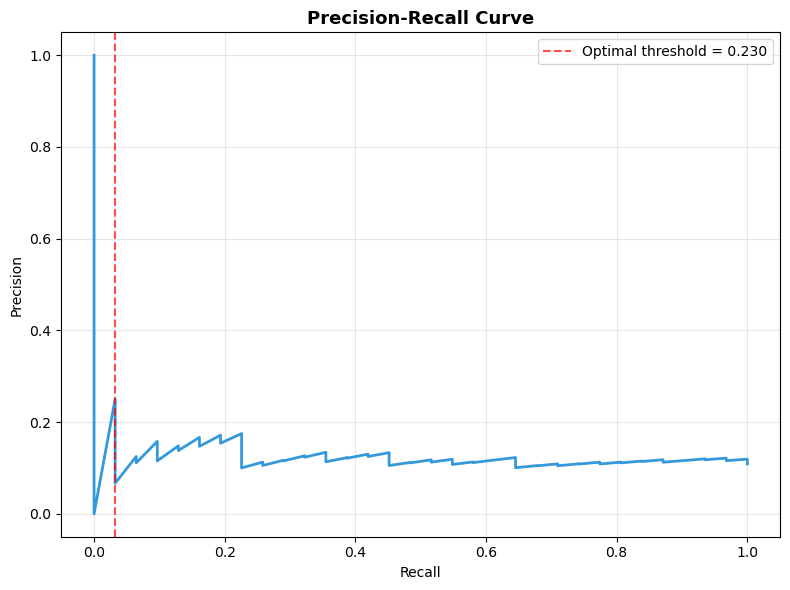

In [18]:
# Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, color='#3498db', lw=2)
plt.axvline(recall_opt, color='red', linestyle='--', alpha=0.7,
            label=f'Optimal threshold = {best_threshold:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve', fontweight='bold', fontsize=13)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


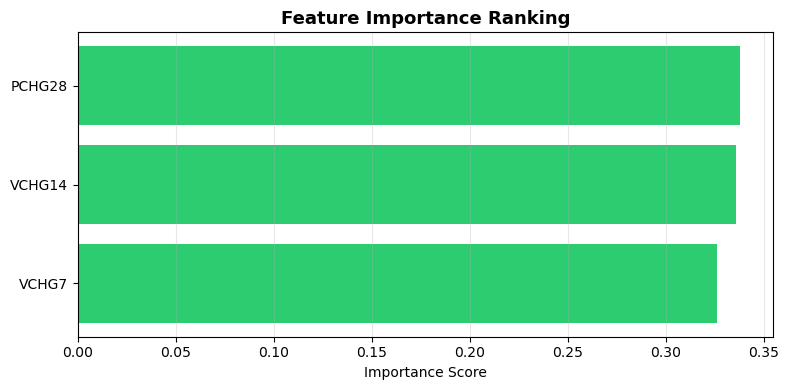

In [19]:
# Feature Importance (Random Forest)
importance_plot = importances[
    importances['Feature'].isin(features_embedded)
].sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(importance_plot['Feature'], importance_plot['Importance'], color='#2ecc71')
plt.xlabel('Importance Score')
plt.title('Feature Importance Ranking', fontweight='bold', fontsize=13)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
# MOM_5 and MOM_10: short-term price momentum is the strongest signal for breakout prediction


In [20]:
# Classification Report
print(classification_report(y_test, y_pred, target_names=['Downtrend', 'Uptrend'], digits=4))
# Downtrend precision ~0.97: downtrend predictions are highly reliable
# Uptrend precision ~0.20: limited by severe class imbalance (8:1)
# ROC AUC remains the most reliable overall metric


              precision    recall  f1-score   support

   Downtrend     0.9091    0.4331    0.5867       254
     Uptrend     0.1220    0.6452    0.2051        31

    accuracy                         0.4561       285
   macro avg     0.5155    0.5391    0.3959       285
weighted avg     0.8235    0.4561    0.5452       285



---
## STEP 7: Backtesting


In [21]:
# Backtesting setup
df_backtest = df_enhanced.iloc[split_idx:].copy()
df_backtest['actual'] = y_test.values

# Strategy 1: default threshold (0.5) — go long when model predicts uptrend
df_backtest['pred_baseline'] = y_pred
df_backtest['ret_baseline']  = df_backtest['pred_baseline'] * df_backtest['RET']
df_backtest['cum_baseline']  = (1 + df_backtest['ret_baseline']).cumprod()
# cumprod: compound return = (1+r1) x (1+r2) x ... x (1+rn)

# Strategy 2: optimised threshold
df_backtest['pred_threshold'] = y_pred_optimized
df_backtest['ret_threshold']  = df_backtest['pred_threshold'] * df_backtest['RET']
df_backtest['cum_threshold']  = (1 + df_backtest['ret_threshold']).cumprod()

# Benchmark: Buy & Hold
df_backtest['cum_market'] = (1 + df_backtest['RET']).cumprod()


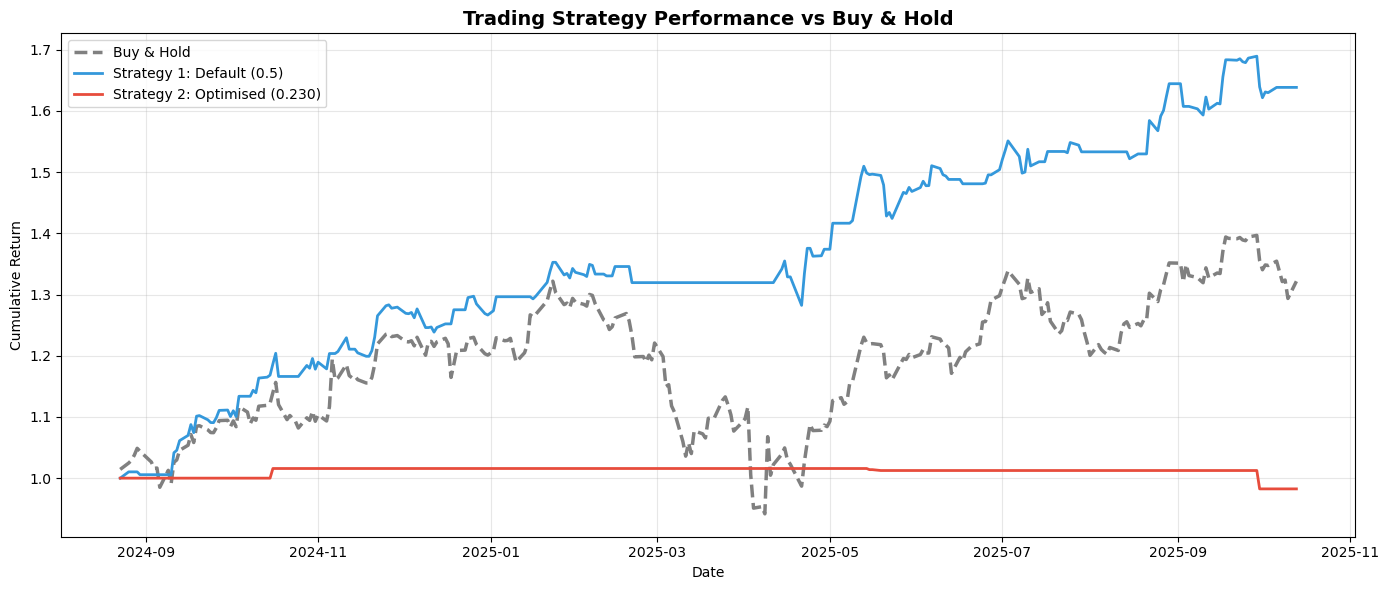

In [22]:
# Strategy performance visualisation
plt.figure(figsize=(14, 6))
plt.plot(df_backtest.index, df_backtest['cum_market'],
         label='Buy & Hold', linewidth=2.5, color='gray', linestyle='--')
plt.plot(df_backtest.index, df_backtest['cum_baseline'],
         label='Strategy 1: Default (0.5)', linewidth=2, color='#3498db')
plt.plot(df_backtest.index, df_backtest['cum_threshold'],
         label=f'Strategy 2: Optimised ({best_threshold:.3f})', linewidth=2, color='#e74c3c')
plt.title('Trading Strategy Performance vs Buy & Hold', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [23]:
# Risk metric functions
def calc_sharpe(returns, periods=252):
    return returns.mean() / returns.std() * np.sqrt(periods) if returns.std() != 0 else np.nan
    # Sharpe = mean daily return / daily std * sqrt(252)
    # Annualises using square-root-of-time rule

def calc_max_dd(cumulative):
    running_max = cumulative.cummax()  # historical peak up to each date
    return ((cumulative - running_max) / running_max).min()
    # Max drawdown = largest peak-to-trough decline

test_years = len(df_backtest) / 252

cum_map = {
    'Buy & Hold':             df_backtest['cum_market'],
    'Strategy 1 (Default)':   df_backtest['cum_baseline'],
    'Strategy 2 (Optimised)': df_backtest['cum_threshold']
}

metrics = {}
for name, cum in cum_map.items():
    rets    = df_backtest['RET'] if name == 'Buy & Hold' else \
              df_backtest['ret_baseline'] if 'Default' in name else df_backtest['ret_threshold']
    ann_ret = (cum.iloc[-1] ** (1 / test_years) - 1) * 100
    max_dd  = calc_max_dd(cum) * 100
    metrics[name] = {
        'Total Return (%)':  round((cum.iloc[-1] - 1) * 100, 2),
        'Annual Return (%)': round(ann_ret, 2),
        'Sharpe Ratio':      round(calc_sharpe(rets), 4),
        'Max Drawdown (%)':  round(max_dd, 2),
        'Trades':            int(len(df_backtest)) if name == 'Buy & Hold' else
                             int(df_backtest['pred_baseline'].sum()) if 'Default' in name else
                             int(df_backtest['pred_threshold'].sum())
    }

results_table = pd.DataFrame(metrics).T
print('Strategy Performance Summary:')
print(results_table.to_string())


Strategy Performance Summary:
                        Total Return (%)  Annual Return (%)  Sharpe Ratio  Max Drawdown (%)  Trades
Buy & Hold                         32.17              27.97        0.9571            -28.76   285.0
Strategy 1 (Default)               63.84              54.74        2.6944             -5.65   164.0
Strategy 2 (Optimised)             -1.75              -1.55       -0.4779             -3.28     4.0


---
## STEP 8: Feature Stability Analysis


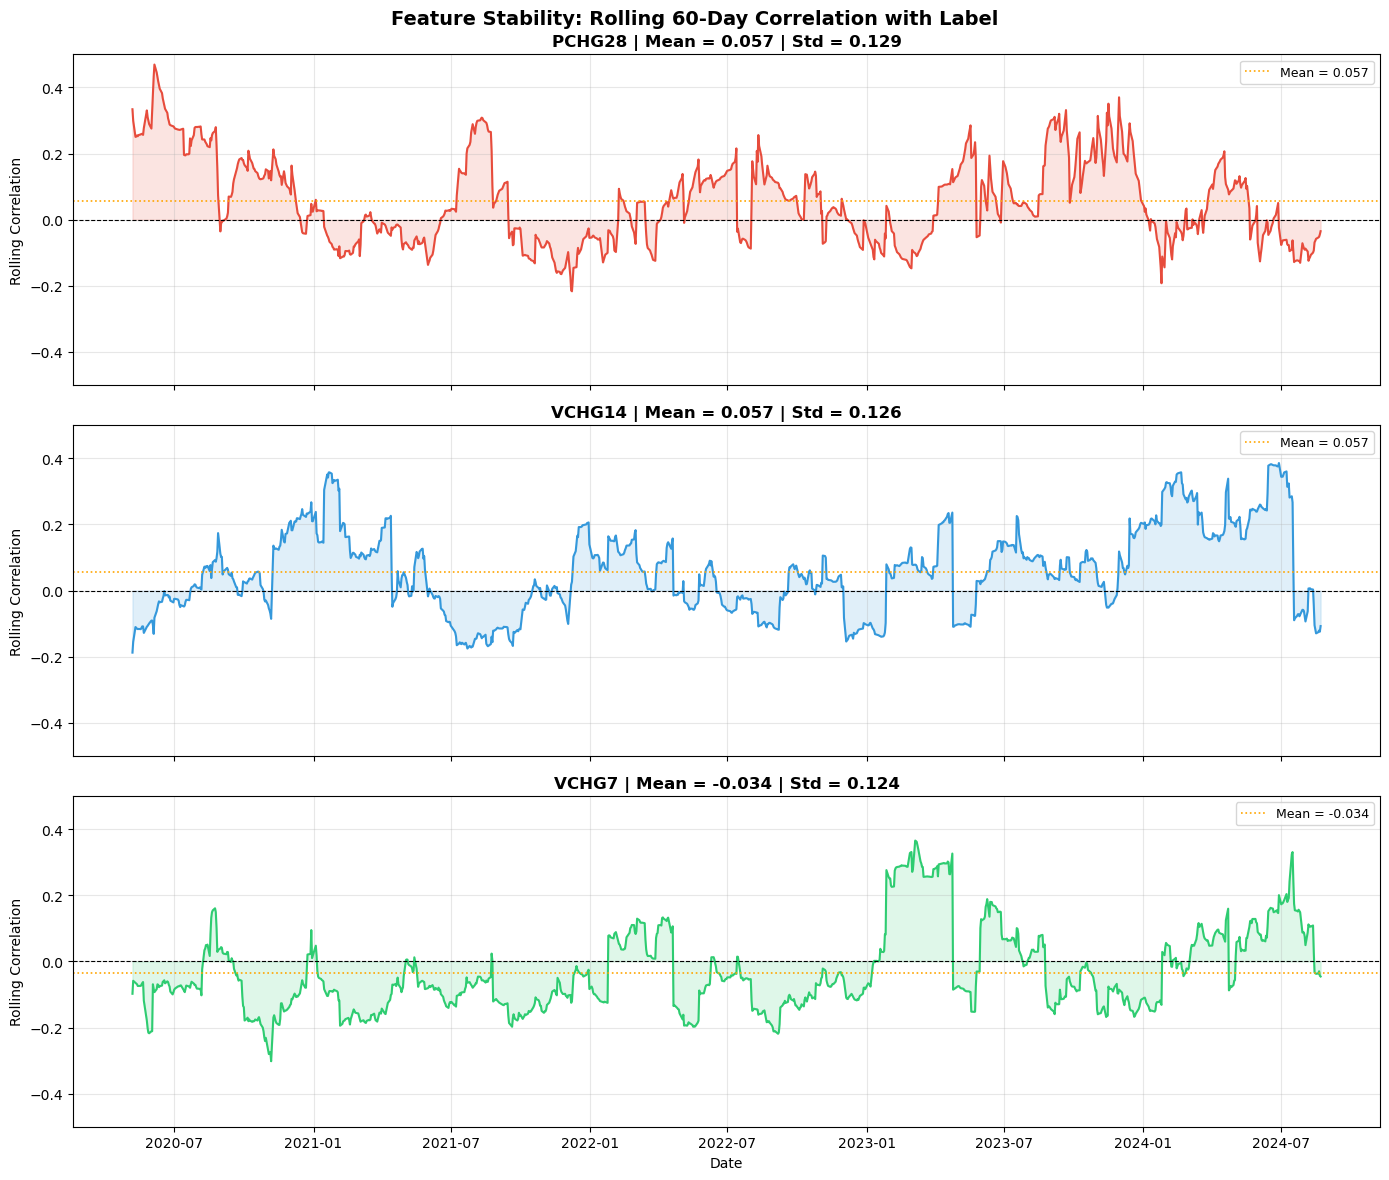

In [24]:
# Feature stability: rolling 60-day correlation with Label
roll_window = 60

stability_df = X_train_final.copy()
stability_df['Label'] = y_train.values

rolling_corr = {}
for feat in features_embedded:
    rolling_corr[feat] = stability_df['Label'].rolling(roll_window).corr(stability_df[feat])
    # Compute Pearson correlation over rolling 60-day window
    # Stable correlation = feature predicts consistently across market regimes

rolling_corr_df = pd.DataFrame(rolling_corr, index=stability_df.index).dropna()

fig, axes = plt.subplots(len(features_embedded), 1,
                          figsize=(14, 4 * len(features_embedded)), sharex=True)
if len(features_embedded) == 1:
    axes = [axes]

colors_feat = ['#e74c3c', '#3498db', '#2ecc71']
for idx, (feat, ax) in enumerate(zip(features_embedded, axes)):
    corr = rolling_corr_df[feat]
    ax.plot(corr.index, corr, color=colors_feat[idx % 3], linewidth=1.5)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.axhline(corr.mean(), color='orange', linewidth=1.2, linestyle=':',
               label=f'Mean = {corr.mean():.3f}')
    ax.fill_between(corr.index, corr, 0, alpha=0.15, color=colors_feat[idx % 3])
    ax.set_title(f'{feat} | Mean = {corr.mean():.3f} | Std = {corr.std():.3f}', fontweight='bold')
    ax.set_ylabel('Rolling Correlation')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.5, 0.5)

axes[-1].set_xlabel('Date')
plt.suptitle(f'Feature Stability: Rolling {roll_window}-Day Correlation with Label',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [25]:
# Stability summary table
stability_summary = pd.DataFrame({
    'Feature':      list(features_embedded),
    'Mean_Corr':    [rolling_corr_df[f].mean() for f in features_embedded],
    'Std_Corr':     [rolling_corr_df[f].std()  for f in features_embedded],
    'Pct_Positive': [(rolling_corr_df[f] > 0).mean() * 100 for f in features_embedded]
    # Pct_Positive > 50%: feature direction consistent — reliable predictor
})
stability_summary['Stability'] = stability_summary['Std_Corr'].apply(
    lambda x: 'High' if x < 0.1 else ('Medium' if x < 0.2 else 'Low')
)
# Std < 0.10 = High stability; 0.10-0.20 = Medium; > 0.20 = Low

print('Feature Stability Summary:')
print(stability_summary.round(4).to_string(index=False))


Feature Stability Summary:
Feature  Mean_Corr  Std_Corr  Pct_Positive Stability
 PCHG28     0.0566    0.1289       60.3145    Medium
 VCHG14     0.0571    0.1263       65.3099    Medium
  VCHG7    -0.0337    0.1241       32.2849    Medium


---
## STEP 9: Risk Analytics — VaR, Expected Shortfall & Volatility Analysis

Industry-standard downside risk metrics across all strategies:

| Metric | Definition |
|--------|------------|
| **VaR 95%/99%** | Max daily loss not exceeded 95%/99% of the time (Basel III) |
| **ES / CVaR 95%** | Average loss when loss exceeds VaR — captures tail risk (FRTB standard) |
| **Ann. Volatility** | Annualised std of returns |
| **Max Drawdown** | Peak-to-trough maximum loss |
| **Calmar Ratio** | Annual Return / Max Drawdown |


In [26]:
# ============================================================
# STEP 9: Risk Analytics — VaR / ES / Volatility / Drawdown
# ============================================================

strategy_returns = {
    'Buy & Hold':             df_backtest['RET'],
    'Strategy 1 (Default)':   df_backtest['ret_baseline'],
    'Strategy 2 (Optimised)': df_backtest['ret_threshold']
}

def calc_var_historical(returns, confidence=0.95):
    """
    Historical Simulation VaR
    Uses empirical return distribution — no normality assumption
    Preserves fat tails present in financial returns
    confidence=0.95 -> 5th percentile of the loss distribution
    """
    return -np.percentile(returns.dropna(), (1 - confidence) * 100)
    # Negative sign: VaR convention reports losses as positive numbers

def calc_es(returns, confidence=0.95):
    """
    Expected Shortfall (CVaR)
    Average loss conditional on loss exceeding VaR
    More conservative than VaR — captures tail risk
    Basel III FRTB replaced VaR with ES as the regulatory standard
    """
    var        = calc_var_historical(returns, confidence)
    tail_losses = returns.dropna()[returns.dropna() <= -var]
    return -tail_losses.mean() if len(tail_losses) > 0 else np.nan

def calc_annualised_vol(returns, periods=252):
    """Annualised volatility: daily std * sqrt(252) — square-root-of-time rule"""
    return returns.dropna().std() * np.sqrt(periods)

def calc_calmar(annual_return_pct, max_drawdown_pct):
    """Calmar Ratio = Annual Return / |Max Drawdown| — return per unit of drawdown risk"""
    return abs(annual_return_pct / max_drawdown_pct) if max_drawdown_pct != 0 else np.nan

# Compute all risk metrics
risk_results = {}
for name, rets in strategy_returns.items():
    ann_ret = (cum_map[name].iloc[-1] ** (1 / test_years) - 1) * 100
    max_dd  = calc_max_dd(cum_map[name]) * 100
    risk_results[name] = {
        'Ann. Return (%)':     round(ann_ret, 2),
        'Ann. Volatility (%)': round(calc_annualised_vol(rets) * 100, 2),
        'Sharpe Ratio':        round(calc_sharpe(rets), 4),
        'VaR 95% (daily)':     round(calc_var_historical(rets, 0.95) * 100, 3),
        'VaR 99% (daily)':     round(calc_var_historical(rets, 0.99) * 100, 3),
        'ES 95% (daily)':      round(calc_es(rets, 0.95) * 100, 3),
        'Max Drawdown (%)':    round(max_dd, 2),
        'Calmar Ratio':        round(calc_calmar(ann_ret, max_dd), 4)
    }

risk_df = pd.DataFrame(risk_results).T
print('=' * 70)
print('Risk Analytics Summary')
print('=' * 70)
print(risk_df.to_string())
print('\nNote: VaR and ES are daily figures — Historical Simulation method')
print('      Annualised figures use 252 trading days convention')


Risk Analytics Summary
                        Ann. Return (%)  Ann. Volatility (%)  Sharpe Ratio  VaR 95% (daily)  VaR 99% (daily)  ES 95% (daily)  Max Drawdown (%)  Calmar Ratio
Buy & Hold                        27.97                30.63        0.9571            2.937            4.643           4.206            -28.76        0.9725
Strategy 1 (Default)              54.74                16.73        2.6944            1.232            2.994           2.168             -5.65        9.6883
Strategy 2 (Optimised)            -1.55                 3.17       -0.4779           -0.000            0.022           0.012             -3.28        0.4736

Note: VaR and ES are daily figures — Historical Simulation method
      Annualised figures use 252 trading days convention


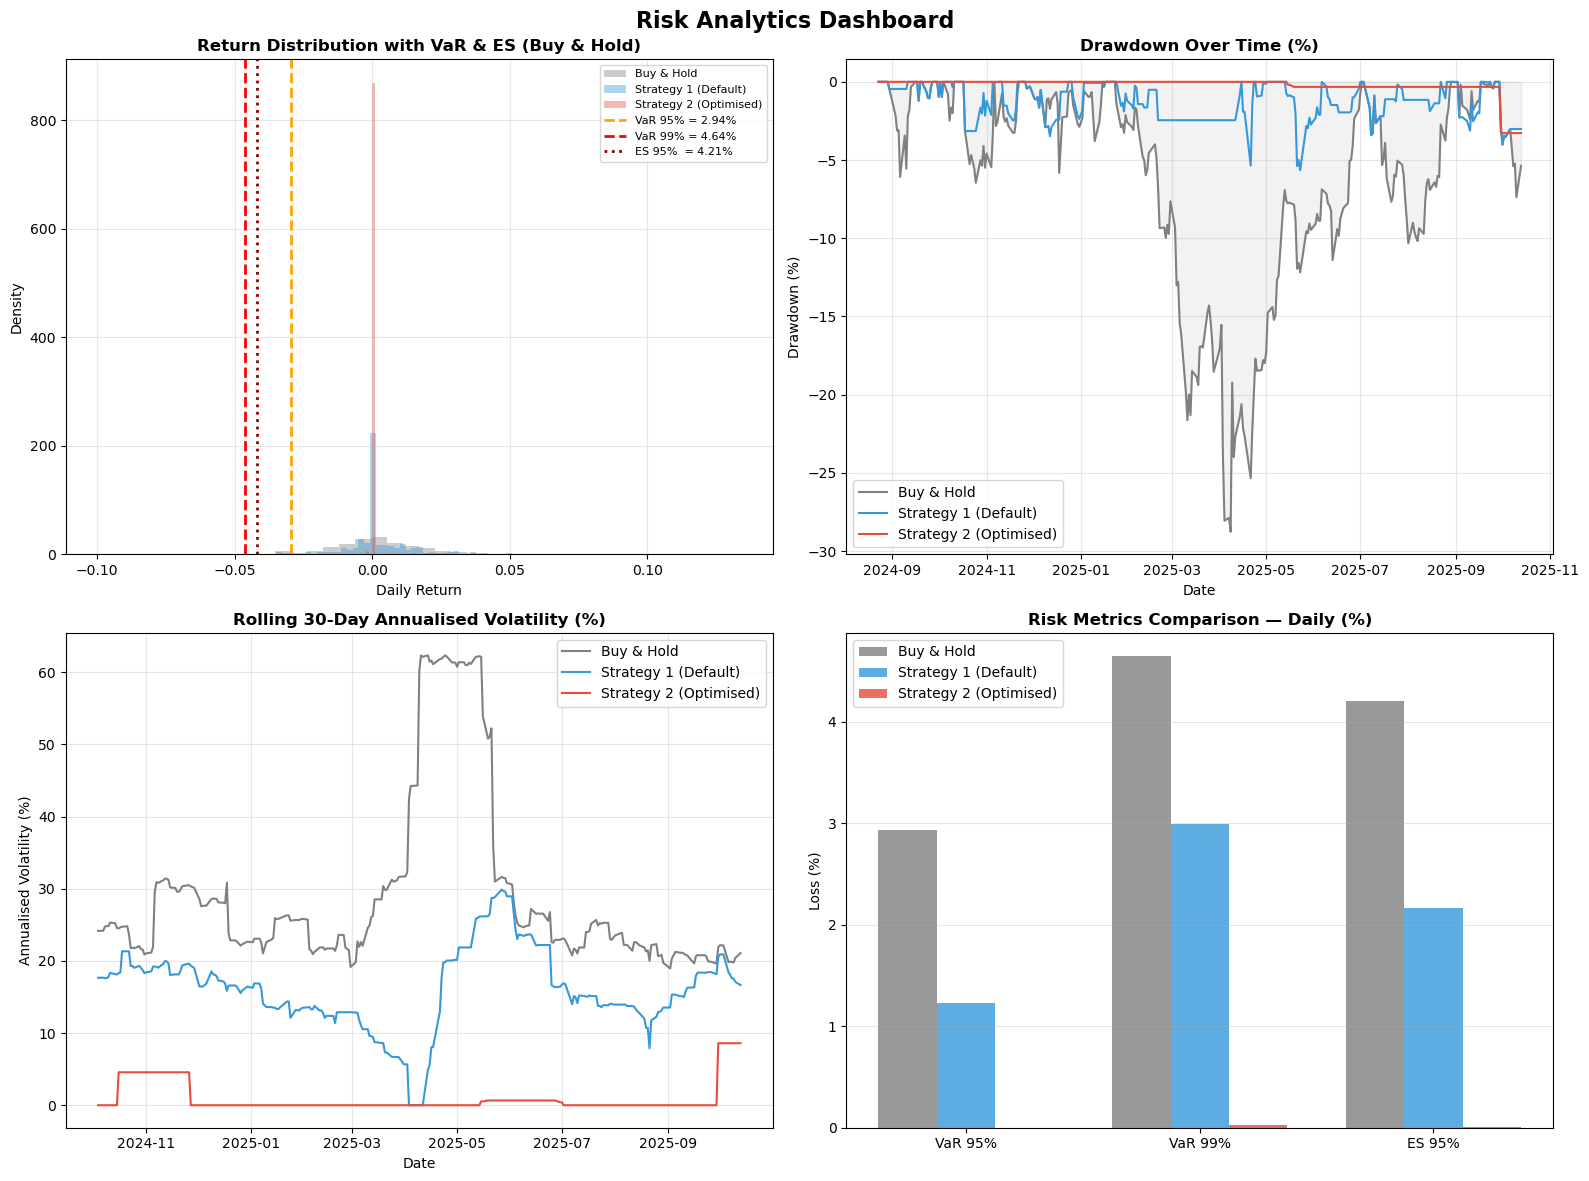

In [27]:
# Risk Analytics Dashboard — 4 charts
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
colors = {'Buy & Hold': 'gray', 'Strategy 1 (Default)': '#3498db', 'Strategy 2 (Optimised)': '#e74c3c'}

# Chart 1: Return distribution with VaR and ES lines
ax1 = axes[0, 0]
for name, rets in strategy_returns.items():
    ax1.hist(rets.dropna(), bins=40, alpha=0.4, color=colors[name], label=name, density=True)
    # density=True: y-axis as probability density — comparable across strategies

bh_rets = strategy_returns['Buy & Hold'].dropna()
var95   = calc_var_historical(bh_rets, 0.95)
var99   = calc_var_historical(bh_rets, 0.99)
es95    = calc_es(bh_rets, 0.95)

ax1.axvline(-var95, color='orange',  linestyle='--', lw=2, label=f'VaR 95% = {var95*100:.2f}%')
ax1.axvline(-var99, color='red',     linestyle='--', lw=2, label=f'VaR 99% = {var99*100:.2f}%')
ax1.axvline(-es95,  color='darkred', linestyle=':',  lw=2, label=f'ES 95%  = {es95*100:.2f}%')
ax1.set_title('Return Distribution with VaR & ES (Buy & Hold)', fontweight='bold')
ax1.set_xlabel('Daily Return')
ax1.set_ylabel('Density')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# Chart 2: Drawdown over time
ax2 = axes[0, 1]
for name, cum in cum_map.items():
    drawdown = (cum - cum.cummax()) / cum.cummax() * 100
    ax2.plot(drawdown.index, drawdown, color=colors[name], label=name, linewidth=1.5)
ax2.fill_between(df_backtest.index,
                 (df_backtest['cum_market'] - df_backtest['cum_market'].cummax()) /
                 df_backtest['cum_market'].cummax() * 100,
                 0, alpha=0.1, color='gray')
ax2.set_title('Drawdown Over Time (%)', fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Drawdown (%)')
ax2.legend()
ax2.grid(alpha=0.3)

# Chart 3: Rolling 30-day annualised volatility
ax3 = axes[1, 0]
for name, rets in strategy_returns.items():
    rolling_vol = rets.rolling(30).std() * np.sqrt(252) * 100
    # rolling(30).std() * sqrt(252): annualise daily vol using 30-day window
    ax3.plot(rolling_vol.index, rolling_vol, color=colors[name], label=name, linewidth=1.5)
ax3.set_title('Rolling 30-Day Annualised Volatility (%)', fontweight='bold')
ax3.set_xlabel('Date')
ax3.set_ylabel('Annualised Volatility (%)')
ax3.legend()
ax3.grid(alpha=0.3)

# Chart 4: Risk metrics comparison bar chart
ax4    = axes[1, 1]
risk_metrics = ['VaR 95% (daily)', 'VaR 99% (daily)', 'ES 95% (daily)']
x     = np.arange(len(risk_metrics))
width = 0.25
for i, (name, color) in enumerate(colors.items()):
    vals = [risk_results[name][m] for m in risk_metrics]
    ax4.bar(x + i * width, vals, width, label=name, color=color, alpha=0.8)
ax4.set_title('Risk Metrics Comparison — Daily (%)', fontweight='bold')
ax4.set_ylabel('Loss (%)')
ax4.set_xticks(x + width)
ax4.set_xticklabels(['VaR 95%', 'VaR 99%', 'ES 95%'])
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.suptitle('Risk Analytics Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


In [28]:
# Risk interpretation summary
print('Risk Interpretation:')
print('-' * 60)
for name in risk_results:
    r = risk_results[name]
    print(f'\n{name}:')
    print(f'  Typical bad day  (VaR 95%): loss up to {r["VaR 95% (daily)"]:.2f}%')
    print(f'  Extreme bad day  (VaR 99%): loss up to {r["VaR 99% (daily)"]:.2f}%')
    print(f'  Tail average loss (ES 95%): avg loss  = {r["ES 95% (daily)"]:.2f}%')
    print(f'  Max Drawdown: {r["Max Drawdown (%)"]:.2f}% | Calmar: {r["Calmar Ratio"]:.3f}')

print('\n' + '-' * 60)
print('Key Takeaway:')
print('Strategy 2 (optimised threshold) trades less frequently,')
print('resulting in lower volatility and smaller drawdowns vs Strategy 1,')
print('at the cost of lower total return — a classic risk-return trade-off.')


Risk Interpretation:
------------------------------------------------------------

Buy & Hold:
  Typical bad day  (VaR 95%): loss up to 2.94%
  Extreme bad day  (VaR 99%): loss up to 4.64%
  Tail average loss (ES 95%): avg loss  = 4.21%
  Max Drawdown: -28.76% | Calmar: 0.973

Strategy 1 (Default):
  Typical bad day  (VaR 95%): loss up to 1.23%
  Extreme bad day  (VaR 99%): loss up to 2.99%
  Tail average loss (ES 95%): avg loss  = 2.17%
  Max Drawdown: -5.65% | Calmar: 9.688

Strategy 2 (Optimised):
  Typical bad day  (VaR 95%): loss up to -0.00%
  Extreme bad day  (VaR 99%): loss up to 0.02%
  Tail average loss (ES 95%): avg loss  = 0.01%
  Max Drawdown: -3.28% | Calmar: 0.474

------------------------------------------------------------
Key Takeaway:
Strategy 2 (optimised threshold) trades less frequently,
resulting in lower volatility and smaller drawdowns vs Strategy 1,
at the cost of lower total return — a classic risk-return trade-off.
